

#Student Performance Prediction Using Machine Learning
## Comparing Behavioural Factors vs Acdemic History





#Introduction
The project explores the factors influencing student academic performance and builds predictive models to estimate final grades (G3). The analysis compares two approaches
-Model A: Includes prior academic performance (G1, G2)
-Model B: Excludes prior academic performance to assess behavioral and environmental impact

#Load Data

In [6]:
import pandas as pd
df = pd.read_csv('student-mat.csv')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


#Data Overview

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

#Data Cleaning


In [8]:
df.isnull().sum()

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


In [9]:
df.duplicated().sum()

np.int64(0)

#Exploratory Data Analysis
##Distribution of Student Performance

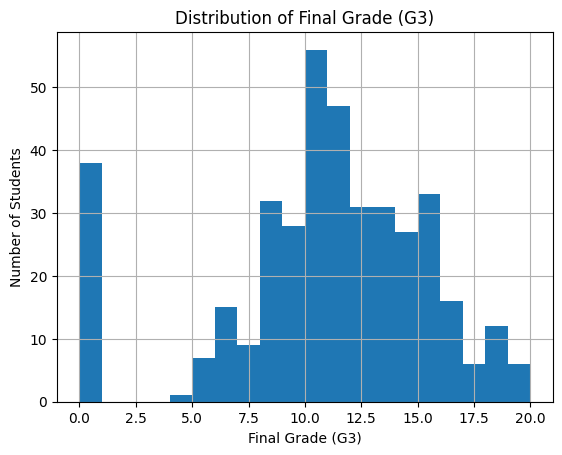

In [10]:
import matplotlib.pyplot as plt
plt.figure()
df['G3'].hist(bins=20)
plt.title('Distribution of Final Grade (G3)')
plt.xlabel('Final Grade (G3)')
plt.ylabel('Number of Students')
plt.show()

#Insight
The distribution of final grades shows that most students score between mid-range values, with concentration around the average. This indicates that overall student performance is moderate with relatively few extremely high or low performers. The presence of a few low -score outliers suggests that a small group of students may be struggling significantly

##Performance by Gender

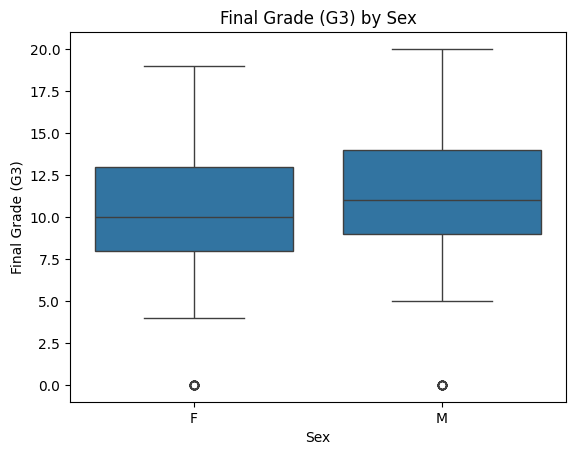

In [11]:
import seaborn as sns
plt.figure()
sns.boxplot(x='sex', y='G3', data = df)
plt.title('Final Grade (G3) by Sex')
plt.xlabel('Sex')
plt.ylabel('Final Grade (G3)')
plt.show()

#Insight
The analysis shows a slight variation in performance between genders; however, the difference is not substantial. Both groups exhibit a similar distribution of scores, suggesting that gender is not a strong determinant of academic performance compared to other influencing factors

##Performance by Paid Extra Classes

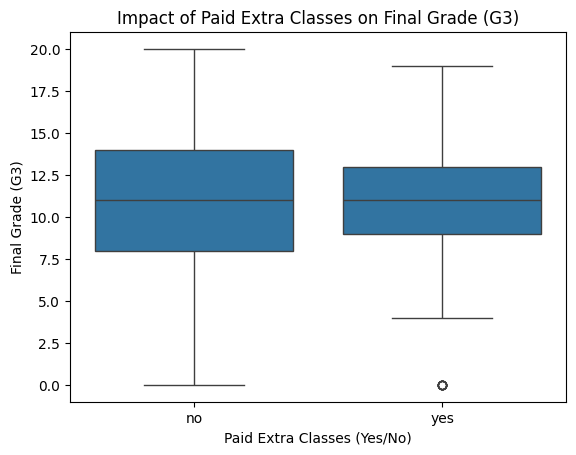

In [12]:
plt.figure()
sns.boxplot(x='paid', y='G3', data = df)
plt.title('Impact of Paid Extra Classes on Final Grade (G3)')
plt.xlabel('Paid Extra Classes (Yes/No)')
plt.ylabel('Final Grade (G3)')
plt.show()

#Insight
Students who attend paid extra classes generally demonstrate slightly higher performance compared to those who do not . This indicates that additional academic support contributes positively to student outcomes, although the difference is moderate, suggesting other facttors also influence performance

#Define Target

In [13]:
y=df['G3']

#Define Features

In [14]:
X=df.drop(['G1', 'G2', 'G3'], axis = 1)



#  Encode Categorical

In [15]:
X = pd.get_dummies(X, drop_first=True)
X.head()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


#Split

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#Model A without (G1,G2)

In [17]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train,y_train)



RandomForestRegressor()

# Predict

In [18]:
y_pred = model.predict(X_test)

#Evaluate

In [19]:
from sklearn.metrics import mean_absolute_error, r2_score
print('MAE:', mean_absolute_error(y_test,y_pred))
print('R2:', r2_score(y_test,y_pred))

MAE: 3.0407594936708864
R2: 0.28689357203138177


#Define Target

In [20]:
y =df['G3']

#Define features





In [21]:
X=df.drop(['G3'], axis=1)

#Encode Categorical

In [22]:
X= pd.get_dummies(X,drop_first=True)
X = X.astype(int)
X.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,1,0,1,0,0,0,1,1,0,0
1,17,1,1,1,2,0,5,3,3,1,...,0,0,0,1,0,0,0,1,1,0
2,15,1,1,1,2,3,4,3,2,2,...,1,0,1,0,1,0,1,1,1,0
3,15,4,2,1,3,0,3,2,2,1,...,1,0,0,1,1,1,1,1,1,1
4,16,3,3,1,2,0,4,3,2,1,...,0,0,0,1,1,0,1,1,0,0


#Train

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#Model B with (G1,G2)

In [24]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train,y_train)

RandomForestRegressor()

Predict

In [25]:
y_pred = model.predict(X_test)

#Evaluate

In [26]:
from sklearn.metrics import mean_absolute_error, r2_score
print('MAE:',mean_absolute_error(y_test,y_pred))
print('R2:',r2_score(y_test,y_pred))

MAE: 1.1360759493670887
R2: 0.811911020379458


#Features Importance

In [27]:
feature_importance = pd.Series(model.feature_importances_,index = X.columns)
feature_importance.sort_values(ascending = False).head(10)

,0
G2,0.782115
absences,0.118556
reason_home,0.019339
age,0.008863
famrel,0.006885
G1,0.006192
health,0.005242
goout,0.004423
schoolsup_yes,0.004345
guardian_mother,0.003711


#Key Findings

1. Prior Academic Performance Dominates Prediction
The model revealed that second-period grades (G2) accounted for approximately 79% of predictive importance, making it the most influential factor in determining final academic outcomes.

2. Attendance Significantly Impacts Performance
Student absences emerged as the second most important feature (~11%), indicating that consistent attendance plays a critical role in academic success.

3. Diminishing Influence of Earlier Grades
Interestingly, first-period grades (G1) contributed minimally once G2 was included, suggesting that more recent performance is a stronger indicator of final outcomes.

4. Limited Impact of Lifestyle Factors
Variables such as social activity, romantic relationships, and family support showed relatively low importance, indicating that these factors alone are insufficient predictors of academic performance.

#Final Output

While behavioral and environmental factors explain a portion of student performance (R² ≈ 0.24), incorporating prior academic results significantly improves predictive accuracy (R² ≈ 0.79). Among all variables, recent academic performance (G2) overwhelmingly dominates prediction, highlighting the importance of continuous academic tracking and intervention